In [83]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random
import seaborn as sns
import pandas as pd
from typing import List, Union, Optional, Tuple
import pickle
import os

from plotting_utils import *
from base_actor_critic import *
from training_utils import *

In [84]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 15 # Time out
GOAL_POS = np.array([0.5, 0.5]) # Goal position
WALL = None
# WALL = [[0.8, 0.0], [0.8, 0.8]]
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 3 # Number of episodes
L2 = 0.000 # L2 regularization


In [85]:
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

In [86]:
def create_experiment(
    dt=0.1,
    t_timeout=15,
    input_min=-1.0,
    input_max=1.0,
    goal_pos=np.array([0.9, 0.9]),
    goal_radius=0.1,
    reward_val=1,
    reward_duration=1,
    wall=None,
    n_placecells=50,
    fta_eta=0.1,
    eta = 0.01,
    l2=0.0,
    tau=5,
    tau_e=5,
    actor_fta_post=[2],
    critic_fta_post=[1],
):
    """Returns a fresh environment, agent, place cells, actor, critic"""
    
    # --- Environment ---
    env = SpatialGoalEnvironment(dt=dt, teleport_on_reset=True, episode_terminate_delay=reward_duration)
    env.exploration_strength = 0
    if wall is not None:
        env.add_wall(wall)
    
    # Reward and goal
    reward = Reward(reward_val, decay="none", expire_clock=reward_duration, dt=dt)
    goals = [SpatialGoal(env, pos=goal_pos, goal_radius=goal_radius, reward=reward)]
    env.goal_cache.reset_goals = goals
    
    # --- Agent ---
    ag = Agent(env, params={'dt': dt})
    env.add_agents(ag)
    
    # --- Place Cells ---
    placecells = PlaceCells(ag, params={'n': n_placecells})
    
    # --- Networks ---
    # actorNN = VxVyGaussianFTA(n_in=placecells.n, post_fta=actor_fta_post)
    actorNN = VxVyGaussianMLP(n_in=placecells.n) #add seed
    criticNN = FTANetwork(n_in=placecells.n, input_min=input_min, input_max=input_max, post_fta=critic_fta_post, eta=fta_eta)
    
    # --- Actor ---
    default_params_actor = {
        "tau": tau,
        "tau_z": tau_e,
        "input_layers": [placecells],
        "NeuralNetworkModule": actorNN,
        "optimizer": lambda params: torch.optim.SGD(params, lr=eta, maximize=True, weight_decay=l2),
        "eligibility_traces": True,
    }
    actor = Actor(ag, params=default_params_actor)
    actor.colormap = "PiYG"
    
    # --- Critic ---
    default_params_critic = {
        "tau": tau,
        "tau_z": tau_e,
        "input_layers": [placecells],
        "NeuralNetworkModule": criticNN,
        "optimizer": lambda params: torch.optim.SGD(params, lr=eta, maximize=True, weight_decay=l2),
        "eligibility_traces": True,
    }
    critic = Critic(ag, params=default_params_critic)
    
    return env, ag, placecells, actor, critic

In [87]:
def plot_rate_maps(env, ag,actor, critic,reward = False, trajectory=False):
    if reward:
        fig, ax = plot_reward_history(env)
    
    fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
    fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

    if trajectory:
        fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][0],t_end=env.episodes['start'][0]); display_reward_patch(fig,ax, reward_pos=GOAL_POS, reward_radius=0.1)

In [88]:
def find_fta_module(net: torch.nn.Module):
    '''Find FTA layer in a network and print the type of each module as it searches'''
    for m in net.modules():
        #print(type(m))
        if isinstance(m, FTA):
            return m
    raise ValueError("No FTA module found in the network.")

In [89]:
def count_elements_above_threshold(all_episode_bins, episode, time_step, threshold, num_bins):
    counts = np.zeros(num_bins)
    for i in range(len(all_episode_bins[episode][time_step])):  # iterate over inner lists
        for b in range(num_bins):  # iterate over positions
            if all_episode_bins[episode][time_step][i][b] > threshold:
                counts[b] += 1
    return counts

In [90]:
def create_fta_hook(fta, ag, env, bins, thres=0.1):
    fta_sparsity = []
    states = []
    time_steps = []
    fta_bins_sparsity = []
    fta_bins = []
    out_arrays = []

    
    def sparsity_function(fta_arr):
        return 1 - (np.sum(fta_arr[fta_arr > thres]) / fta_arr.size)

    def hook_fn(module, inputs, output):
        out_arr = output.detach().cpu().numpy().flatten()
        # print(f"FTA output: {out_arr}, shape: {out_arr.shape}")
        fta_b = np.array_split(out_arr, bins)
        # print(f"FTA bins: {fta_b} length: {len(fta_b)}")
        fta_sparse_bins = [sparsity_function(b) for b in fta_b]
        fta_sparsity.append(sparsity_function(out_arr))
        states.append(np.copy(ag.pos))  # or placecells.get_state()
        time_steps.append(env.t)
        fta_bins_sparsity.append(fta_sparse_bins)
        fta_bins.append(fta_b)
        out_arrays.append(out_arr)


    return hook_fn, fta_sparsity, states, time_steps,fta_bins, fta_bins_sparsity, out_arrays


In [91]:
def run_multiple_episodes_with_fta(
    n_episodes,
    env,
    ag,
    actor,
    critic,
    placecells,
    fta,
    num_bins,
    time_limit=15
):
    """
    Runs multiple episodes, records FTA sparsity at each timestep.

    Returns:
        all_episode_sparsity: list of lists of sparsity values (one per episode)
        all_episode_time: list of lists of time steps (one per episode)
    """
    
    all_episode_sparsity = []
    all_episode_time = []
    all_episodes_state = []
    all_episode_bins_sparsity = []
    all_episode_bins = []
    all_out_arrays = []

    try: 
        for i in (pbar := tqdm(range(n_episodes), desc = "")):
            # Reset environment and agent
            env.reset()
            # ag.reset()  # Uncomment if your agent has a reset method

            # Create new FTA hook for this episode
            hook_fn, fta_sparsity, fta_states, fta_times, fta_bins, fta_bins_sparsity, out_arrays = create_fta_hook(fta, ag, env, bins=num_bins)
            handle = fta.register_forward_hook(hook_fn)

            
            # Run one episode
            run_episode(env, ag, actor, critic, state_cells=[placecells], time_limit=time_limit, seed=i)

            # Remove hook
            handle.remove()

            # Store episode data
            all_episode_sparsity.append(fta_sparsity)
            all_episode_time.append(fta_times)
            all_episodes_state.append(fta_states)
            all_episode_bins_sparsity.append(fta_bins_sparsity)
            all_episode_bins.append(fta_bins)
            all_out_arrays.append(out_arrays)
            
            success_frac = np.mean(np.array(env.episodes['meta_info'][-100:]) == "completed")
            episode_time = np.mean(env.episodes['duration'][-100:])
            pbar.set_description(f"<success fraction>: {success_frac:.2f}, <episode time> {episode_time:.1f}")
            if success_frac > 0.99 and i > 10: break
    except KeyboardInterrupt:
        print("Interrupted by user")

    
    return all_episode_sparsity, all_episode_time, all_episodes_state,all_episode_bins, all_episode_bins_sparsity, all_out_arrays

In [92]:
def plot_sparsity_over_episodes(all_episode_sparsity, all_episode_time):
    n = len(all_episode_sparsity)  

    plt.figure(figsize=(6,4))

    for i in range(n):
        plt.plot(all_episode_time[i], all_episode_sparsity[i], label=f"Episode {i+1}")

    plt.xlabel("Time step")
    plt.ylabel("FTA sparsity")
    plt.title("FTA sparsity across episodes")
    plt.legend()
    plt.show()

In [110]:
def compute_dead_neurons_per_timestep(runs_out_arrays, thres=0.1):
    """
    Computes the average percentage of inactive (dead) features per timestep
    across multiple runs, truncating to the minimum number of timesteps.

    Args:
        runs_out_arrays: list of runs, each run is a list of episodes,
                         each episode is a list of out_arrays per timestep
        thres: threshold below which a feature is considered inactive

    Returns:
        mean_dead_percent: array of mean % inactive features per timestep
    """
    # Flatten episodes per run
    flattened_runs = []
    for run in runs_out_arrays:
        # concatenate all timesteps from all episodes in the run
        run_timesteps = []
        for ep_out in run:
            run_timesteps.extend(ep_out)  # ep_out is list of arrays per timestep
        flattened_runs.append(run_timesteps)
    
    # Find minimum number of timesteps across runs
    min_timesteps = min(len(r) for r in flattened_runs)
    
    # Truncate and compute percentage of dead neurons per timestep
    dead_percent = []
    for t in range(min_timesteps):
        timestep_values = np.array([run[t] for run in flattened_runs])  # shape: (num_runs, n_features)
        inactive = timestep_values < thres
        percent_inactive = inactive.mean(axis=1) * 100  # % per run
        dead_percent.append(percent_inactive.mean())   # average across runs
    
    return np.array(dead_percent)



def plot_dead_neurons_over_time(dead_percent, dt=0.1):
    """
    Plots percentage of inactive neurons over time.

    Args:
        dead_percent: array of % inactive features per timestep
        dt: time step duration to convert timestep index to seconds
    """
    timesteps = np.arange(len(dead_percent))
    plt.figure(figsize=(8,4))
    plt.plot(timesteps, dead_percent, color='red', lw=2)
    plt.xlabel("Timesteps")
    plt.ylabel("Percentage of inactive features (%)")
    plt.title("Dead Neurons Over Time")

    # Remove grid
    plt.grid(False)

    # Remove top and right borders
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()

In [ ]:
def compute_dead_neurons_per_episode(runs_out_arrays, thres=0.1):
    """
    Computes the percentage of inactive neurons per episode.
    
    Procedure:
        1. Compute inactivity per timestep
        2. Average across timesteps within each episode
        3. Average across runs

    Args:
        runs_out_arrays: list[runs][episodes][timesteps][features]
        thres: threshold below which a feature is considered inactive

    Returns:
        mean_dead_percent: array (% dead neurons per episode averaged across runs)
    """

    num_runs = len(runs_out_arrays)

    # find minimum number of episodes across runs
    min_episodes = min(len(run) for run in runs_out_arrays)

    dead_percent_runs = []

    for run in runs_out_arrays:
        run_episode_values = []

        for ep in range(min_episodes):
            ep_out = run[ep]  # list of timestep feature vectors

            ep_out = np.array(ep_out)  # shape: (timesteps, features)

            inactive = ep_out < thres

            # percentage inactive per timestep
            percent_timestep = inactive.mean(axis=1) * 100

            # average across timesteps
            percent_episode = percent_timestep.mean()

            run_episode_values.append(percent_episode)

        dead_percent_runs.append(run_episode_values)

    dead_percent_runs = np.array(dead_percent_runs)

    # average across runs
    mean_dead_percent = dead_percent_runs.mean(axis=0)

    return mean_dead_percent


def plot_dead_neurons_per_episode(dead_percent):
    """
    Plot percentage of inactive neurons per episode.
    """

    episodes = np.arange(len(dead_percent))

    plt.figure(figsize=(8,4))
    plt.plot(episodes, dead_percent, lw=2)
    plt.xlabel("Episode")
    plt.ylabel("Percentage of inactive features (%)")
    plt.title("Dead Neurons per Episode")
    plt.grid(True, alpha=0.3)
    plt.show()

In [100]:
num_runs = 1
runs_out_arrays = []
runs_timesteps = []
runs_bins = []
runs_states = []

for i in tqdm(range(num_runs), desc="Running experiments"):   
    set_seed(i)

    env, ag, placecells, actor, critic = create_experiment(dt=0.1, fta_eta=0.1, input_min=-1, input_max=1, t_timeout=T_TIMEOUT, goal_pos=GOAL_POS, goal_radius=GOAL_RADIUS, reward_val=REWARD, reward_duration=REWARD_DURATION, wall=WALL, n_placecells=50)
    fta = find_fta_module(critic.NeuralNetworkModule)
    all_episode_sparsity, all_episode_time, all_episodes_state, all_episode_bins, all_episode_bins_sparsity, all_out_arrays = run_multiple_episodes_with_fta(n_episodes=N_EPISODES, env=env, ag=ag, actor=actor, critic=critic, placecells=placecells, fta=fta, num_bins=20, time_limit=T_TIMEOUT)
    runs_out_arrays.append(all_out_arrays)
    runs_timesteps.append(all_episode_time)
    runs_bins.append(all_episode_bins)
    runs_states.append(all_episodes_state)




Running experiments:   0%|          | 0/1 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Actor does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:892: UserWarning: Cannot check the keys in the params dictionary, as <class 'base_actor_critic.Actor'> does not have a class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Critic does not have the class attribute 'default_params' defined in its preamble.

 fta_eta: 0.1, n_tilings: 1, n_tiles: 10


Running experiments: 100%|██████████| 1/1 [00:00<00:00,  3.65it/s]


In [107]:
env.episodes

{'episode': [1, 2, 3, 4],
 'start': [0, 6.499999999999993, 9.799999999999981, 24.800000000000082],
 'end': [6.499999999999993, 9.799999999999981, 24.800000000000082],
 'duration': [6.499999999999993, 3.2999999999999883, 15.000000000000101],
 'meta_info': ['completed', 'completed', 'timeout']}

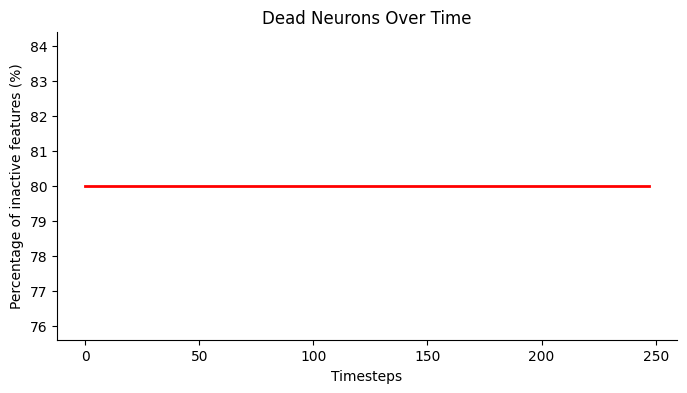

In [111]:
dead_neurons_per_timestep = compute_dead_neurons_per_timestep(runs_out_arrays, thres=0.1)
plot_dead_neurons_over_time(dead_neurons_per_timestep, dt=DT)

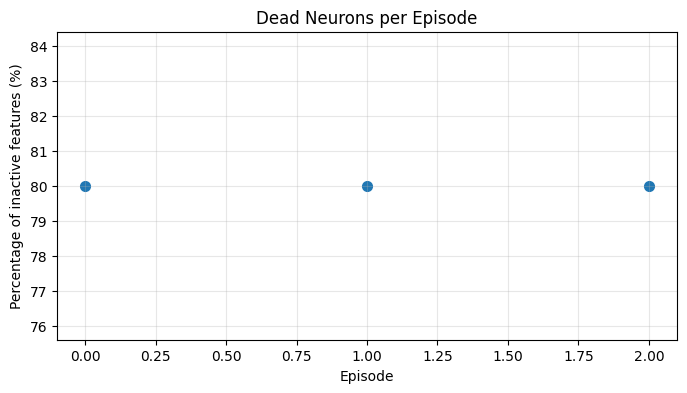

In [109]:
dead_neurons_per_episode = compute_dead_neurons_per_episode(runs_out_arrays, thres=0.1)
plot_dead_neurons_per_episode(dead_neurons_per_episode)

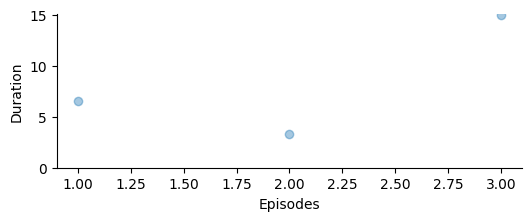

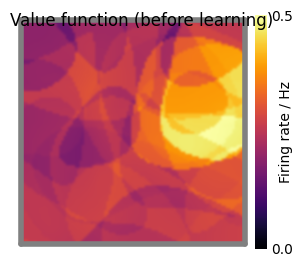

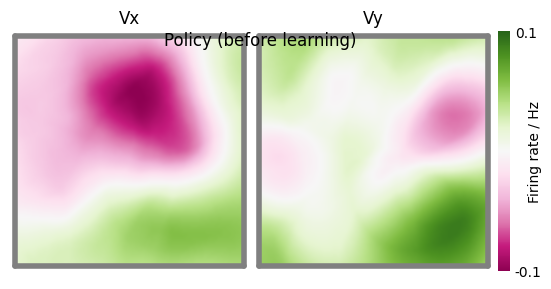

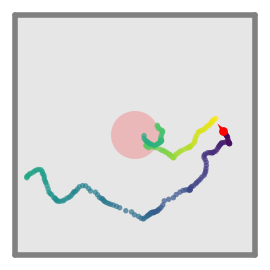

In [112]:
plot_rate_maps(env,ag,actor, critic,reward=True,trajectory=True)

In [98]:
print(len(all_episode_sparsity), len(all_episode_time), len(all_episodes_state), len(all_episode_bins_sparsity), len(all_episode_bins[0]), len(all_out_arrays[0]))
print(env.t/env.dt) # time steps per episode
assert all(len(lst) == 20 for lst in all_episode_bins[0]), "Not all lists have length 20"
# print(all_count_bins)


3 3 3 3 65 65
248.00000000000082


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (65,) and arg 1 with shape (65, 200).

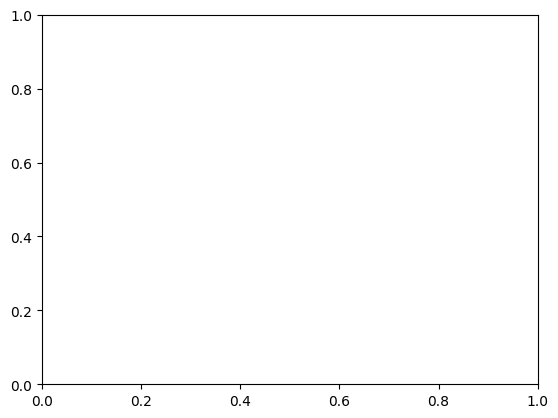

In [99]:
# All units of the last layer

x = np.arange(len(all_out_arrays[0]))

plt.bar(x, all_out_arrays[0])
plt.show()



In [ ]:
threshold = 0.1
episode = 0
time_step = 45
num_bins = 10


plt.bar(np.arange(num_bins), all_count_bins[episode][time_step])
plt.xlabel("Bins")
plt.ylabel(f"Count")
# plt.title("Count of elements above threshold at each position")
plt.show()

NameError: name 'all_count_bins' is not defined

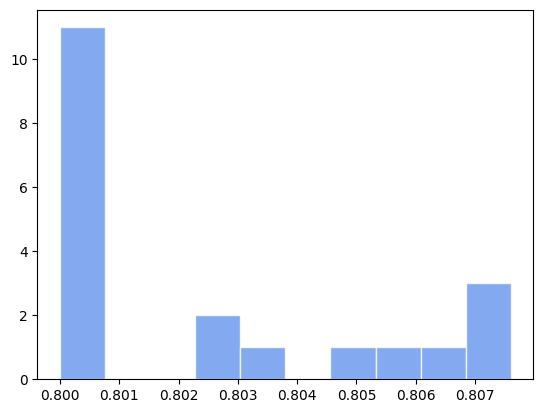

In [ ]:
# Histogram of sparsity values in the first bin across the episode

plt.hist(all_episode_bins_sparsity[0][0], color='cornflowerblue', edgecolor='white', alpha=0.8)
plt.show()